In [16]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_groq import ChatGroq
from duckduckgo_search import DDGS
from rag import retriver
import os
from dotenv import load_dotenv
load_dotenv()

True

In [17]:
class SupportState(TypedDict):
    query: str
    result: str
    solved: Literal["yes","no"]
    next_agent: str
    final_answer: str

In [25]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

def choose_agent(state: SupportState):
    prompt = f"""Read user query and decide which agent to use.
    'rag' - for questions about company policies, refunds, returns, account issues, offers
    'web' - for delivery tracking, real-time information, order status  
    'escalate' - ONLY when user explicitly says 'talk to human' or 'speak to agent'
    Return only one word: rag, web, or escalate.
    user query: {state['query']}"""
    response = llm.invoke(prompt)
    return {"next_agent":response.content.strip().lower()}

def rag_agent(state: SupportState):
    docs = retriver.invoke(state["query"])
    return {"result": "\n".join([d.page_content for d in docs])}

def web_agent(state: SupportState):
    with DDGS() as ddgs:
        results = list(ddgs.text(state['query'], max_results=3))
    output = "\n".join([r['body'] for r in results])
    return {"result":output}

def escalate_agent(state: SupportState):
      return {"result": "My name is Kanhaiya and I'm here to solve your query. Please describe your issue."}


def responder(state: SupportState):
    print(f"{state['result']}\n\nDoes Your Query solved???")
    user_input = input("Type Here: ")
    if user_input.strip().lower() == "yes":
        print("Thanks For Your Patience.\n\nPlease Give us Feedback")
        state["solved"] = "yes"
    else:
        state["solved"] = "no"
    return state


def agent_router(state: SupportState):
    return state["next_agent"]

def router(state: SupportState):
    if state["solved"] == 'yes':
        return "yes"
    else:
        return "no"

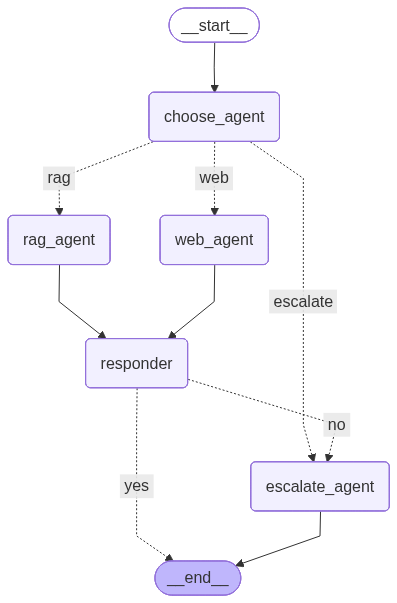

In [26]:
graph = StateGraph(SupportState)
graph.add_node("choose_agent",choose_agent)
graph.add_node("rag_agent",rag_agent)
graph.add_node("web_agent",web_agent)
graph.add_node("escalate_agent",escalate_agent)
graph.add_node("responder",responder)

graph.add_edge(START,"choose_agent")
graph.add_conditional_edges("choose_agent",agent_router,{"web":"web_agent","rag":"rag_agent","escalate":"escalate_agent"})
graph.add_conditional_edges("responder",router,{"yes":END,"no":"escalate_agent"})
graph.add_edge("rag_agent", "responder")
graph.add_edge("web_agent", "responder")
graph.add_edge("escalate_agent", END)

workflow = graph.compile()
workflow

In [27]:
workflow.invoke({
    "query": "what is your refund policy?",
    "result": "",
    "solved": "no",
    "next_agent": "",
    "final_answer": ""
})

3. RETURN POLICY
General Note: The return policy on the individual product page overrides the general policy. All products in a category may not have the same return options.

3.1 General Rules for All Returns
- Returns must be requested within the return window.
- Products must be unused, undamaged, with all original accessories, manuals, warranty cards, and packaging.
- For mobile/laptop/tablet: disable screen lock, remove iCloud lock, and format the device before return.
- Open Box Delivery: If a product is different/damaged at the time of open box acceptance, a refund (including on‑spot for COD) will be given. After acceptance, no return for non‑defective reasons.

3.2 Part 1 – Category‑wise Return Window, Actions & Conditions
(Reference table simplified. “/” means “or”.)
2.3 Cancellation by Seller / Flipkart
- Sellers or Flipkart may cancel an order (in whole or part) due to:
    • Product unavailability
    • Force majeure (unforeseeable events)
    • Suspected fraudulent activit

{'query': 'what is your refund policy?',
 'result': '3. RETURN POLICY\nGeneral Note: The return policy on the individual product page overrides the general policy. All products in a category may not have the same return options.\n\n3.1 General Rules for All Returns\n- Returns must be requested within the return window.\n- Products must be unused, undamaged, with all original accessories, manuals, warranty cards, and packaging.\n- For mobile/laptop/tablet: disable screen lock, remove iCloud lock, and format the device before return.\n- Open Box Delivery: If a product is different/damaged at the time of open box acceptance, a refund (including on‑spot for COD) will be given. After acceptance, no return for non‑defective reasons.\n\n3.2 Part 1 – Category‑wise Return Window, Actions & Conditions\n(Reference table simplified. “/” means “or”.)\n2.3 Cancellation by Seller / Flipkart\n- Sellers or Flipkart may cancel an order (in whole or part) due to:\n    • Product unavailability\n    • Forc